## 10. Bilateral filtering:

(a) Write a Python function to manually implement a bilateral filter for grayscale images. Take as input a grayscale image, a kernel diameter, a spatial standard deviation σs, and a range (intensity) standard deviation σr

In [2]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

In [5]:
f = cv.imread(r'C:\Users\94775\Desktop\msc\Semester III\Computer Vision\258764G\emma.jpg', cv.IMREAD_GRAYSCALE)
assert f is not None, 'Image not found'

In [6]:
def bilateral_filter(f, diameter, sigma_s, sigma_r):
    M, N    = f.shape[:2]
    g       = np.zeros((M, N), dtype=np.float32)
    pad     = diameter // 2
    f_pad   = np.pad(f, pad, mode='reflect').astype(np.float32)
 
    for i in range(M):
        for j in range(N):
            window = f_pad[i : i + diameter, j : j + diameter]
 
            x = np.arange(-(pad), pad + 1)
            Y_g, X_g = np.meshgrid(x, x)
            Gs = np.exp(-(X_g**2 + Y_g**2) / (2 * sigma_s**2))
 
            Gr = np.exp(-((window - f_pad[i + pad, j + pad])**2) / (2 * sigma_r**2))
 
            W  = Gs * Gr
            Wp = np.sum(W)   
 
            g[i, j] = np.sum(W * window) / Wp
 
    return g.astype(np.uint8)

(b) Apply Gaussian smoothing using OpenCV’s cv.GaussianBlur() function

In [8]:
g_gaussian = cv.GaussianBlur(f, (9, 9), 0)

(c) Bilateral filtering using OpenCV’s cv.bilateralFilter() function.

In [9]:
g_bilateral_cv = cv.bilateralFilter(f, 9, 75, 75)

(d) Your manually implemented bilateral filter from part (a).

In [7]:
g_bilateral_manual = bilateral_filter(f, diameter=9, sigma_s=75, sigma_r=75)

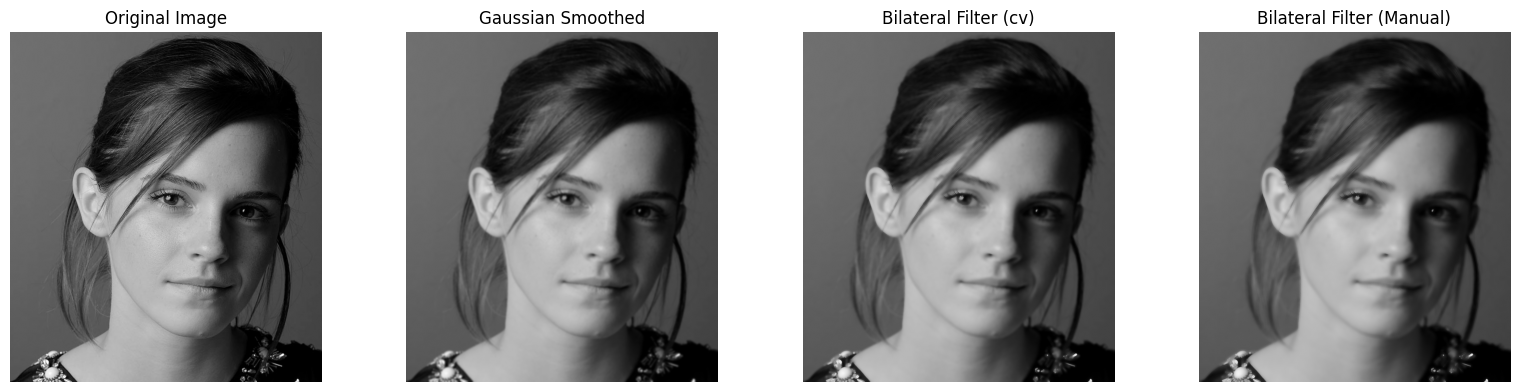

In [10]:
fig, ax = plt.subplots(1, 4, figsize=(16, 4))
 
ax[0].imshow(f,cmap='gray', vmin=0, vmax=255)
ax[0].set_title('Original Image')
ax[0].axis('off')
 
ax[1].imshow(g_gaussian,cmap='gray', vmin=0, vmax=255)
ax[1].set_title('Gaussian Smoothed')
ax[1].axis('off')
 
ax[2].imshow(g_bilateral_cv,cmap='gray', vmin=0, vmax=255)
ax[2].set_title('Bilateral Filter (cv)')
ax[2].axis('off')
 
ax[3].imshow(g_bilateral_manual,cmap='gray', vmin=0, vmax=255)
ax[3].set_title('Bilateral Filter (Manual)')
ax[3].axis('off')
 
plt.tight_layout()
plt.show()